### PCA and Regression Analysis of NWMP Water Sampling Data (Maharashtra)
Roll No: 23052120

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error
import geopandas as gpd

In [2]:
july = pd.read_csv("data/july.csv", encoding="latin1")
aug  = pd.read_csv("data/august.csv", encoding="latin1")
sep  = pd.read_csv("data/september.csv", encoding="latin1")

common_cols = july.columns.intersection(aug.columns).intersection(sep.columns)
july, aug, sep = july[common_cols], aug[common_cols], sep[common_cols]

train_raw = pd.concat([july, aug], ignore_index=True)
test_raw  = sep.copy()

In [3]:
drop_cols = [
    'STN Code', 'Sampling Date', 'Month', 'Sampling Time', 'Stn Name',
    'Type Water Body', 'Name Of Water Body', 'River Basin', 'District',
    'State Name', 'Mon Agency', 'Frequency', 'Major Polluting Sources',
    'Use Based Class', ' Visibility Effluent Discharge', 'Weather',
    'Approx Depth', 'Human Activities', 'Floating Matter', 'Color', 'Odor', 'Flow'
]

TARGETS = ['Potassium', 'Flouride']

def prep(df):
    d = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')
    d = d.apply(pd.to_numeric, errors='coerce')
    d = d.dropna(thresh=int(0.5 * d.shape[1]))
    d = d.fillna(d.median(numeric_only=True))
    return d

train = prep(train_raw)
test  = prep(test_raw)

shared      = train.columns.intersection(test.columns)
train, test = train[shared], test[shared]

feat_cols = [c for c in shared if c not in TARGETS + ['latitude', 'longitude']]

scaler   = StandardScaler()
Xs_train = scaler.fit_transform(train[feat_cols])
Xs_test  = scaler.transform(test[feat_cols])

## Task 1: PCA Projection

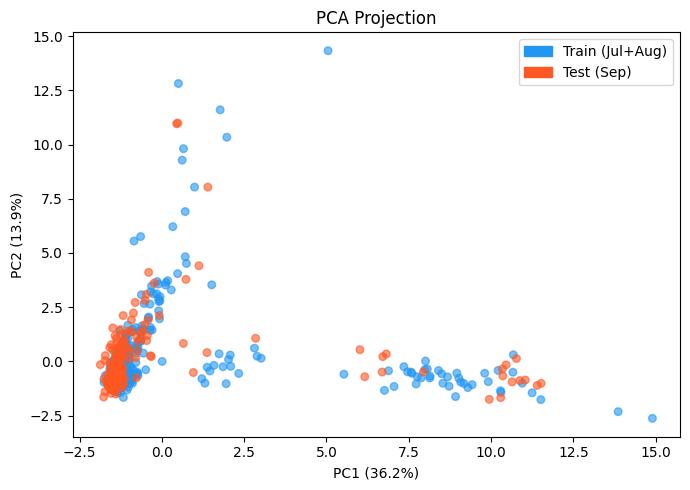

In [4]:
pca       = PCA(n_components=2)
pca_train = pca.fit_transform(Xs_train)
pca_test  = pca.transform(Xs_test)
ev        = pca.explained_variance_ratio_

all_pca = np.vstack([pca_train, pca_test])
colors  = ['#2196F3'] * len(pca_train) + ['#FF5722'] * len(pca_test)

plt.figure(figsize=(7, 5))
plt.scatter(all_pca[:, 0], all_pca[:, 1], c=colors, alpha=0.6, s=30)
plt.legend(handles=[
    mpatches.Patch(color='#2196F3', label='Train (Jul+Aug)'),
    mpatches.Patch(color='#FF5722', label='Test (Sep)')
])
plt.xlabel(f"PC1 ({ev[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({ev[1]*100:.1f}%)")
plt.title("PCA Projection")
plt.tight_layout()
plt.show()

## Task 2: Regression – Potassium & Fluoride

Potassium  ->  Linear MSE: 1385.8884   |   Logistic MSE: 0.2818


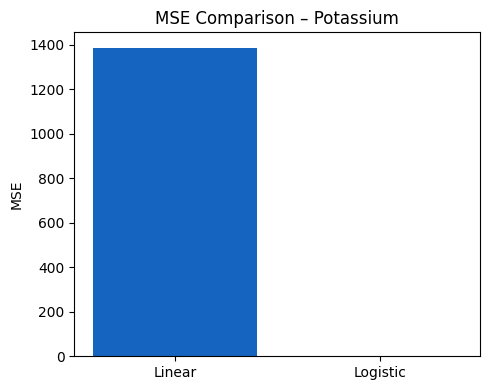

Flouride  ->  Linear MSE: 0.2165   |   Logistic MSE: 0.5141


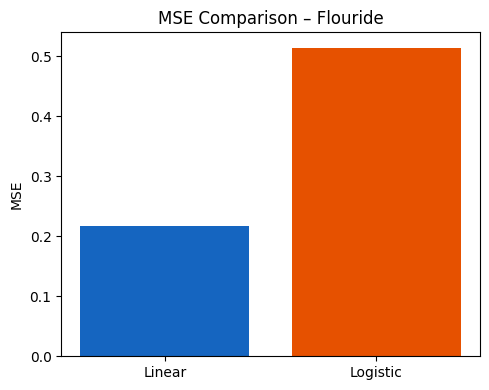

In [5]:
for target in TARGETS:
    y_tr = train[target]
    y_te = test[target]

    lr        = LinearRegression().fit(Xs_train, y_tr)
    mse_lr    = mean_squared_error(y_te, lr.predict(Xs_test))

    threshold = y_tr.median()
    y_tr_bin  = (y_tr >= threshold).astype(int)
    y_te_bin  = (y_te >= threshold).astype(int)
    log       = LogisticRegression(max_iter=500).fit(Xs_train, y_tr_bin)
    mse_log   = mean_squared_error(y_te_bin, log.predict_proba(Xs_test)[:, 1])

    print(f"{target}  ->  Linear MSE: {mse_lr:.4f}   |   Logistic MSE: {mse_log:.4f}")

    plt.figure(figsize=(5, 4))
    plt.bar(['Linear', 'Logistic'], [mse_lr, mse_log], color=['#1565C0', '#E65100'])
    plt.title(f"MSE Comparison – {target}")
    plt.ylabel("MSE")
    plt.tight_layout()
    plt.show()

## Task 3: Map of India – Chemical Elements by Location

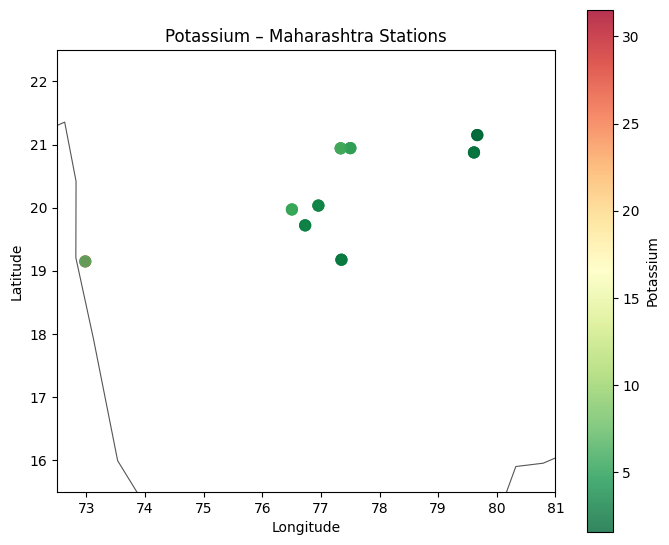

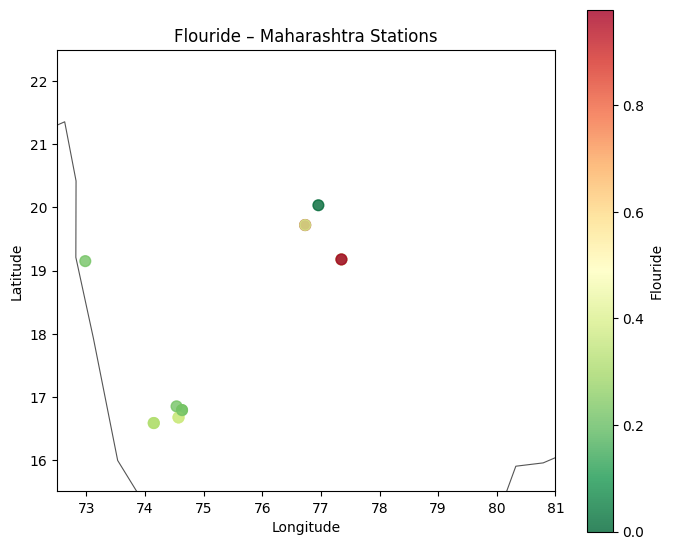

In [6]:
full = pd.concat([july, aug, sep], ignore_index=True)
full = full.apply(lambda c: pd.to_numeric(c, errors='coerce')
                  if c.name not in ['STN Code','Stn Name','State Name','District'] else c)
map_df = full.dropna(subset=['latitude', 'longitude'])

world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)
name_col = 'ADMIN' if 'ADMIN' in world.columns else 'name'
india = world[world[name_col] == "India"]

for elem in TARGETS:
    sub = map_df.dropna(subset=[elem])

    fig, ax = plt.subplots(figsize=(7, 9))
    india.boundary.plot(ax=ax, linewidth=0.8, color='#555')
    ax.set_xlim(72.5, 81.0)
    ax.set_ylim(15.5, 22.5)

    sc = ax.scatter(sub['longitude'], sub['latitude'],
                    c=sub[elem], cmap='RdYlGn_r', s=60, alpha=0.8)
    plt.colorbar(sc, ax=ax, shrink=0.6).set_label(elem)
    ax.set(title=f"{elem} – Maharashtra Stations",
           xlabel="Longitude", ylabel="Latitude")
    plt.tight_layout()
    plt.show()